<a href="https://colab.research.google.com/github/sj-workbench/years_of_learnings/blob/main/polynomial_linear3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import r2_score

In [33]:
x = 6* np.random.rand(200,1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200,1)

# y = 0.8x^2 + 0.9x + 2

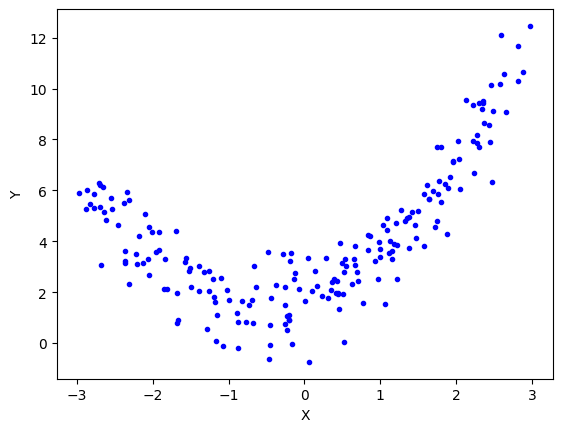

In [34]:
plt.plot(x,y, 'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [36]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [37]:
y_pred = lr.predict(x_test)

In [38]:
acc = r2_score(y_test,y_pred)
acc

0.32605049951666176

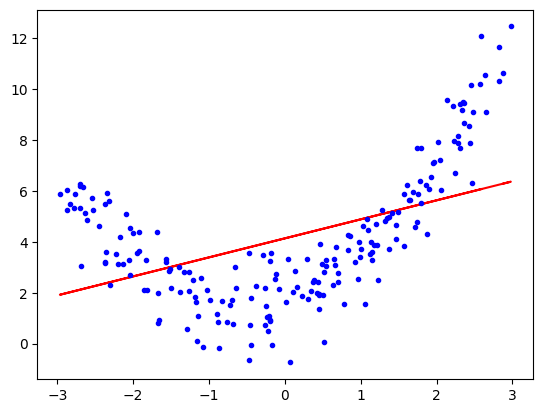

In [39]:
plt.plot(x_train,lr.predict(x_train), color= 'r')
plt.plot(x,y, 'b.')
plt.show()

In [40]:
# Applying polynomial Regression
poly = PolynomialFeatures(degree =2 ) # include_bias parameter is True (by default). Keeping it False gonna remove (1) [i.e = x0]
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [41]:
print(x_train[0])
print(x_train_trans[0])

[2.58827861]
[1.         2.58827861 6.69918614]


In [42]:
lr = LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [43]:
y_predict = lr.predict(x_test_trans)

In [44]:
r2_score(y_test,y_predict)

0.83233595335855

In [48]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.92046144 0.8358714 ]]
[1.8532495]


In [50]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

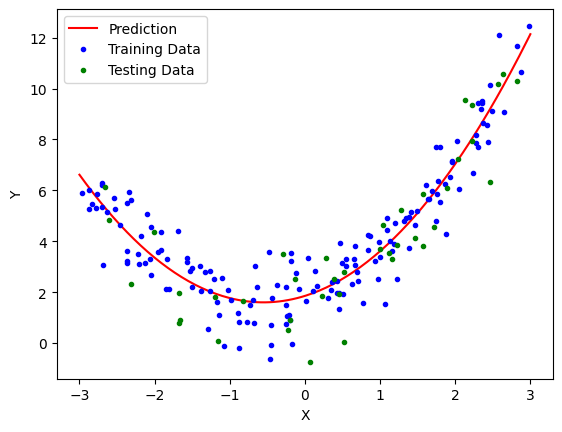

In [51]:
plt.plot(x_new,y_new, color = 'r', label = "Prediction")
plt.plot(x_train,y_train, 'b.', label = "Training Data")
plt.plot(x_test,y_test, 'g.', label = "Testing Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()